## 2 (60%) 製程效能預測與健康狀態分析（Process Performance Prediction and Health Status Analysis）
本題使用 PHM Data Challenge 2016 所提供之化學機械研磨（Chemical Mechanical Planarization,
CMP）製程資料。CMP 為半導體製造中關鍵的平坦化製程，其材料去除率（Average Removal
Rate）會隨著製程參數設定以及設備與耗材（如 polishing pad 與 dresser）的使用與劣化狀態而
產生變化。本資料集包含 CMP 製程中的時間序列感測資料與對應的晶圓平均材料去除率。每一
筆觀測資料由 25 個製程與設備相關變數（例如壓力、轉速、漿液流量與耗材使用量）所組成，
並以晶圓編號（WAFER_ID）與製程階段（STAGE A/B）為單位，對應一個平均材料去除率
（AVG_REMOVAL_RATE）作為預測目標。

## 2.1 (5%) 製造數據分析架構與資料摘要
本專案將進行完整的數據分析架構，如下方流程圖:讀取資料集後將進行品質檢查、共線性診斷、離群值處理、特徵工程，接著進行分組建模，並比較五種模型效能，驗證採用嚴謹的`TimeSeries Nested CV`+`Sliding Window`，並在最後依據模型結果進行決策建議。


<img src="../reports/figures/project_workflow.jpg" alt="流程圖" width="50%" style="display: block; margin: 0 auto;" />

容我先把需要用的套件花一大個Cell輸入在這


In [5]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

from skopt import BayesSearchCV
from skopt.callbacks import DeltaYStopper
from skopt.space import Real, Categorical, Integer

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

下方Cell進行基本資料摘要分析，輸出包含：
- **樣本數與變數數量**
- **不同製程階段 (STAGE A/B) 下不同機台 (CHAMBER) 的資料分布**
- **目標變數 AVG_REMOVAL_RATE 的基本統計特性**

原始時間序列資料總筆數: 672744, 變數數量: 25
目標值資料總筆數: 1981

--- 資料基本摘要 ---

--- 樣本數與變數數量 ---
不重複晶圓數量 (WAFER_ID): 1699

--- 不同製程階段 (STAGE) 與機台 (CHAMBER) 的資料分布 ---
  STAGE  CHAMBER  Data Points
0     A      1.0        54649
1     A      2.0        21062
2     A      3.0        27010
3     A      4.0       147701
4     A      5.0        68613
5     A      6.0        57824
6     B      4.0       160441
7     B      5.0        71593
8     B      6.0        63851

--- 目標變數 AVG_REMOVAL_RATE 的基本統計特性 ---
count    1981.000000
mean       98.631645
std       187.429160
min        53.426550
25%        72.376500
50%        79.154850
75%        88.702050
max      4326.154050
Name: AVG_REMOVAL_RATE, dtype: float64


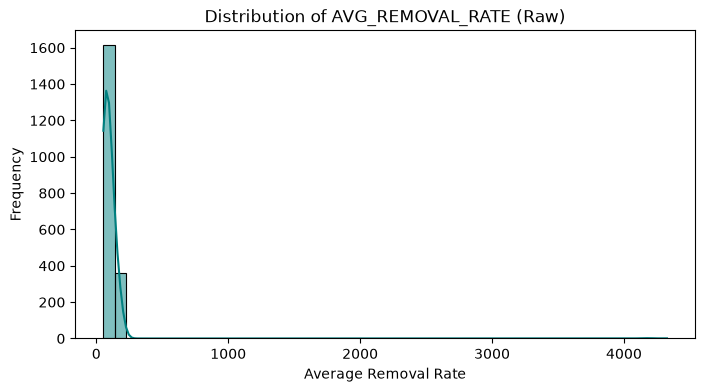

In [6]:
## ====================================================================
## 2.1 資料載入與基本摘要 (Data Loading & Summary)
## ====================================================================
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = str(PROJECT_ROOT / 'data' / 'raw' / 'training')
LABEL_PATH = str(PROJECT_ROOT / 'data' / 'raw' / 'labels' / 'CMP-training-removalrate.csv')

all_files = glob.glob(os.path.join(DATA_PATH, '*.csv'))
df_list = [pd.read_csv(file) for file in all_files]
big_df = pd.concat(df_list, ignore_index=True)
print(f"原始時間序列資料總筆數: {len(big_df)}, 變數數量: {big_df.shape[1]}")

y_df = pd.read_csv(LABEL_PATH)
print(f"目標值資料總筆數: {len(y_df)}")

print("\n--- 資料基本摘要 ---")
print("\n--- 樣本數與變數數量 ---")
print(f"不重複晶圓數量 (WAFER_ID): {big_df['WAFER_ID'].nunique()}")

print("\n--- 不同製程階段 (STAGE) 與機台 (CHAMBER) 的資料分布 ---")
distribution = big_df.groupby(['STAGE', 'CHAMBER']).size().reset_index(name='Data Points')
print(distribution)

print("\n--- 目標變數 AVG_REMOVAL_RATE 的基本統計特性 ---")
print(y_df['AVG_REMOVAL_RATE'].describe())

plt.figure(figsize=(8, 4))
sns.histplot(y_df['AVG_REMOVAL_RATE'], bins=50, kde=True, color='teal')
plt.title("Distribution of AVG_REMOVAL_RATE (Raw)")
plt.xlabel("Average Removal Rate")
plt.ylabel("Frequency")
plt.show()





## 2.2 (5%) 資料品質檢查與前處理
本資料集中存在以下潛在的資料品質問題與對應之前處理策略：
- **重複樣本**：存在相同 `WAFER_ID` 的重複標籤紀錄，但經檢查發現是因為有些晶圓會同時存在STAGE A/B的資料。故本資料集不存在重複樣本。
- **異常值 / 量測異常**：極端的材料去除率（小於 10 或大於 300）通常為機台量測異常，故予以濾除。
- **缺失值與特徵對齊**：不同機台經歷路徑導致部分特徵出現空值，後續採用常數填補（補 0）。
- **冗餘欄位**：`MACHINE_ID`完全無變異(剃除)，`MACHINE_DATA`和`CHAMBER`完全共線(剔除`MACHINE_DATA`)

移除重複標籤後的晶圓數量: 1981

--- 濾除目標變數異常值 ---
清洗前標籤筆數: 1981
清洗後標籤筆數: 1977
🔪 成功踢除了 4 筆極端異常資料 (Outliers)


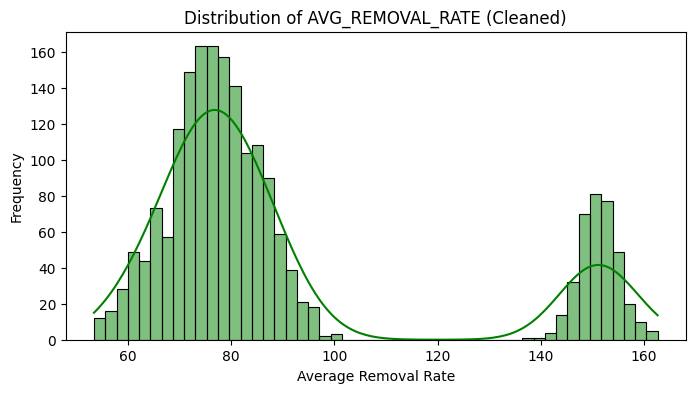

MACHINE_ID的類別個數: 1
--- 檢查 MACHINE_DATA 與 CHAMBER 的共線性 ---
MACHINE_DATA 與 CHAMBER 的交叉比對表:
CHAMBER         1.0    2.0    3.0     4.0     5.0     6.0
MACHINE_DATA                                             
1             54649      0      0       0       0       0
2                 0  21062      0       0       0       0
3                 0      0  27010       0       0       0
4                 0      0      0  308142       0       0
5                 0      0      0       0  140206       0
6                 0      0      0       0       0  121675
✅ 結論：MACHINE_DATA 與 CHAMBER 呈現完全一對一映射 (完全共線)！後續特徵工程將剔除MACHINE_DATA。


In [4]:
## ====================================================================
## 2.2 資料清洗 (Data Cleaning)
## ====================================================================
# 2.1 處理重複樣本
y_df = y_df.drop_duplicates(subset=['WAFER_ID','STAGE']).set_index('WAFER_ID')
print(f"移除重複標籤後的晶圓數量: {len(y_df)}")

# 2.2 濾除目標變數 (AVG_REMOVAL_RATE) 的極端異常值
print("\n--- 濾除目標變數異常值 ---")

UPPER_LIMIT = 300
LOWER_LIMIT = 10 

clean_mask = (y_df['AVG_REMOVAL_RATE'] < UPPER_LIMIT) & (y_df['AVG_REMOVAL_RATE'] > LOWER_LIMIT)

original_count = len(y_df)
y_cleaned_df = y_df[clean_mask]
cleaned_count = len(y_cleaned_df)

print(f"清洗前標籤筆數: {original_count}")
print(f"清洗後標籤筆數: {cleaned_count}")
print(f"🔪 成功踢除了 {original_count - cleaned_count} 筆極端異常資料 (Outliers)")


plt.figure(figsize=(8, 4))
sns.histplot(y_cleaned_df['AVG_REMOVAL_RATE'], bins=50, kde=True, color='green')
plt.title("Distribution of AVG_REMOVAL_RATE (Cleaned)")
plt.xlabel("Average Removal Rate")
plt.ylabel("Frequency")
plt.show()
# 2.4無變異欄位和高共線性變數
print("MACHINE_ID的類別個數:",big_df['MACHINE_ID'].nunique())
print("--- 檢查 MACHINE_DATA 與 CHAMBER 的共線性 ---")
cross_tab = pd.crosstab(big_df['MACHINE_DATA'], big_df['CHAMBER'])
print("MACHINE_DATA 與 CHAMBER 的交叉比對表:")
print(cross_tab)
is_collinear = (cross_tab > 0).sum(axis=1).max() == 1 and (cross_tab > 0).sum(axis=0).max() == 1
if is_collinear:
    print("✅ 結論：MACHINE_DATA 與 CHAMBER 呈現完全一對一映射 (完全共線)！後續特徵工程將剔除MACHINE_DATA。")
else:
    print("⚠️ 結論：兩者並非完全一對一映射。")


## 2.3 (10%) 探索性分析與製程診斷 (EDA)
以下分別針對壓力類變數、流液變數、耗材類變數、轉速類變數及剩餘變數分別對Timestamp作圖，以此觀察各種X對Y的關係，以及相似X欄位的關係。
我們可以觀察到`AIRBAG壓力變數`及`耗材類變數`皆存在高度共線性，並藉此作為後續特徵工程篩選的依據。
此外，可以藉由圖可以發現無論哪項變數，雖然幾乎都有極端值的出現，但其實都是系統性的離群，因此給予我在2.2不對x做離群值處理的理由。



正在針對所有資料點進行作圖 (Scatter Plot)...


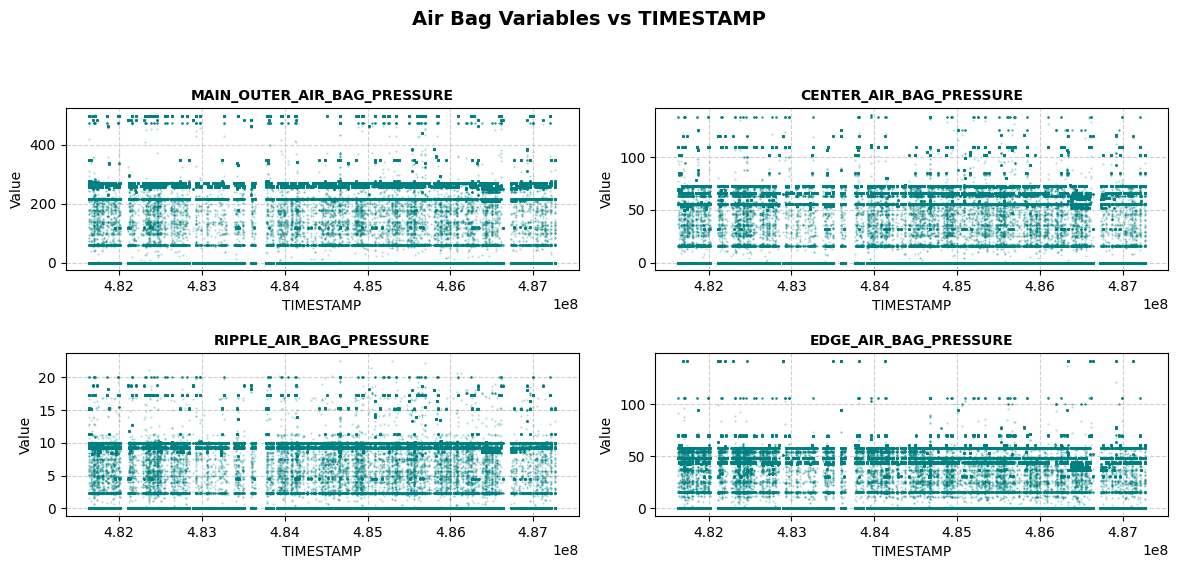

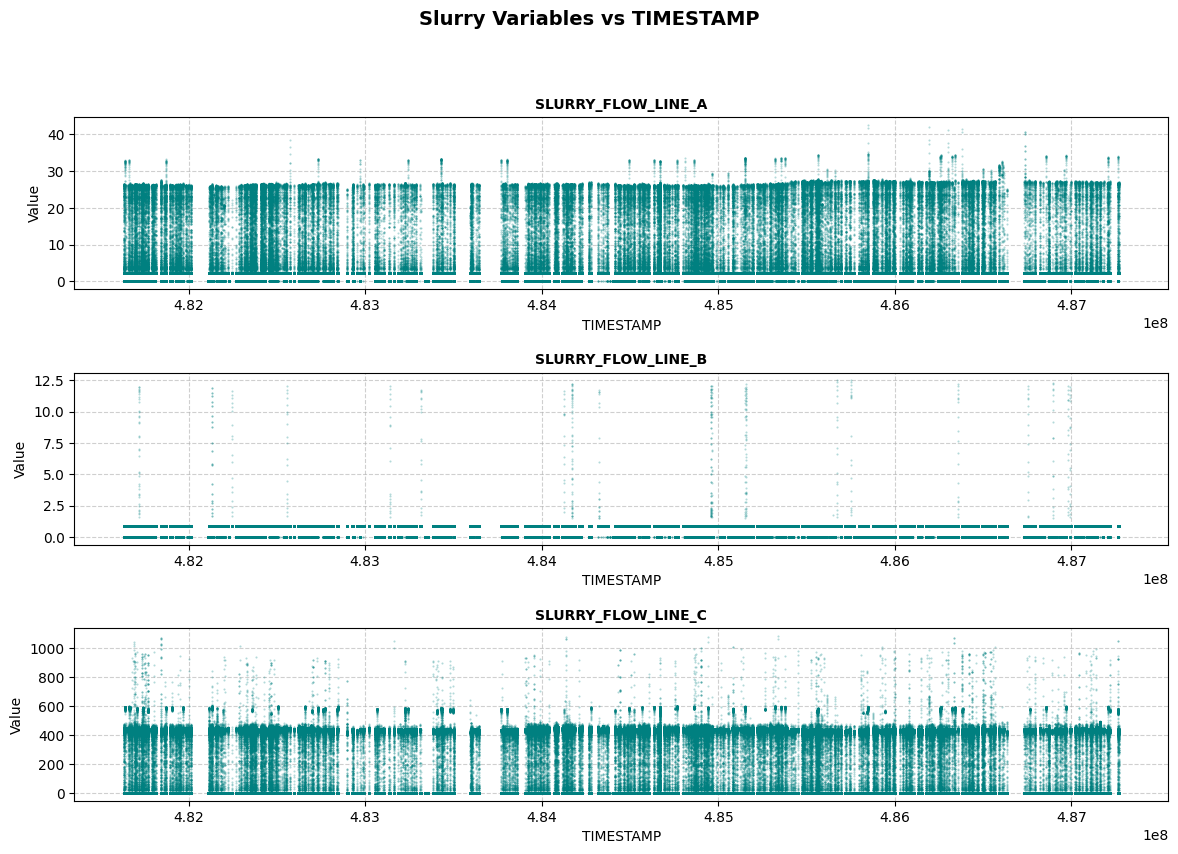

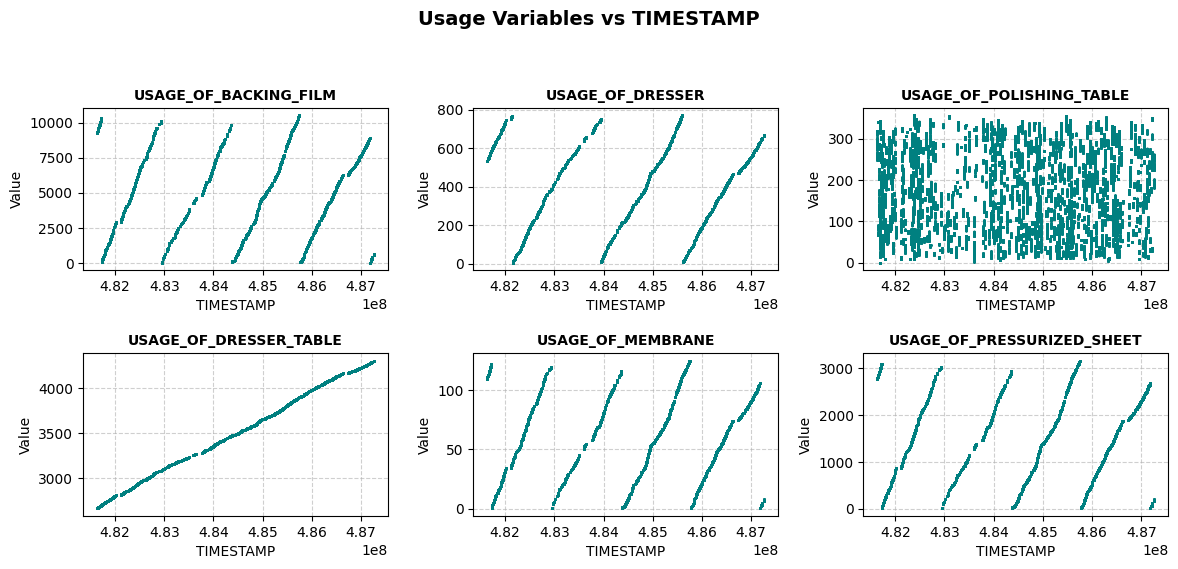

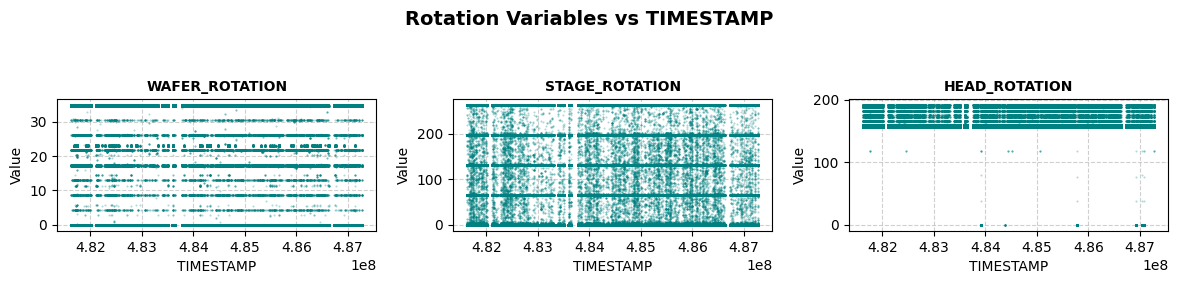

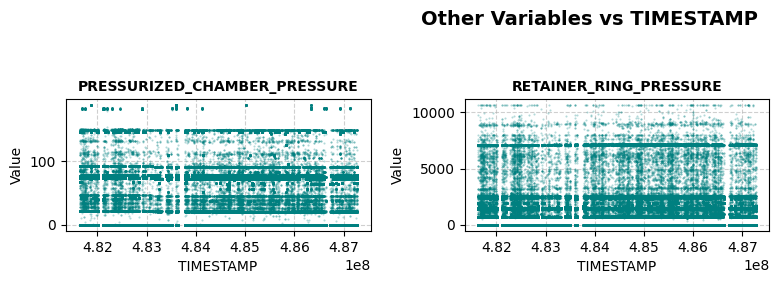


正在檢查氣囊壓力變數之間的相關性 (共線性檢查)...
氣囊壓力相關係數矩陣:
                             MAIN_OUTER_AIR_BAG_PRESSURE  \
MAIN_OUTER_AIR_BAG_PRESSURE                     1.000000   
CENTER_AIR_BAG_PRESSURE                         0.995413   
RIPPLE_AIR_BAG_PRESSURE                         0.992507   
EDGE_AIR_BAG_PRESSURE                           0.969346   

                             CENTER_AIR_BAG_PRESSURE  RIPPLE_AIR_BAG_PRESSURE  \
MAIN_OUTER_AIR_BAG_PRESSURE                 0.995413                 0.992507   
CENTER_AIR_BAG_PRESSURE                     1.000000                 0.991983   
RIPPLE_AIR_BAG_PRESSURE                     0.991983                 1.000000   
EDGE_AIR_BAG_PRESSURE                       0.971621                 0.975646   

                             EDGE_AIR_BAG_PRESSURE  
MAIN_OUTER_AIR_BAG_PRESSURE               0.969346  
CENTER_AIR_BAG_PRESSURE                   0.971621  
RIPPLE_AIR_BAG_PRESSURE                   0.975646  
EDGE_AIR_BAG_PRESSURE                   

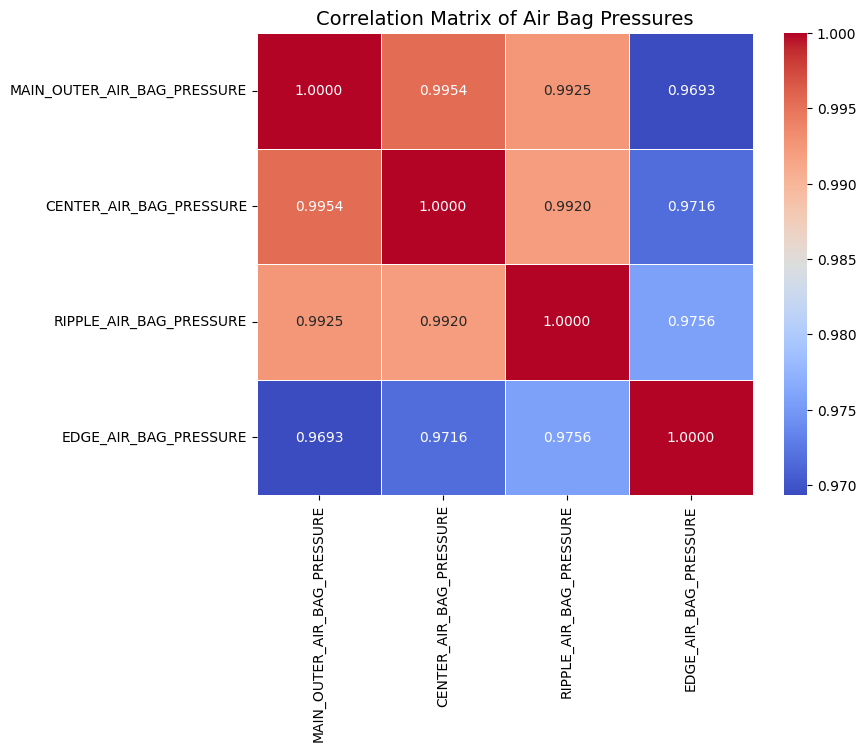


正在檢查耗材使用量 (USAGE) 變數之間的相關性 (共線性檢查)...
耗材使用量相關係數矩陣:
                            USAGE_OF_BACKING_FILM  USAGE_OF_DRESSER  \
USAGE_OF_BACKING_FILM                    1.000000          0.017113   
USAGE_OF_DRESSER                         0.017113          1.000000   
USAGE_OF_POLISHING_TABLE                 0.008076         -0.040624   
USAGE_OF_DRESSER_TABLE                   0.061918         -0.000440   
USAGE_OF_MEMBRANE                        1.000000          0.017113   
USAGE_OF_PRESSURIZED_SHEET               1.000000          0.017113   

                            USAGE_OF_POLISHING_TABLE  USAGE_OF_DRESSER_TABLE  \
USAGE_OF_BACKING_FILM                       0.008076                0.061918   
USAGE_OF_DRESSER                           -0.040624               -0.000440   
USAGE_OF_POLISHING_TABLE                    1.000000               -0.008125   
USAGE_OF_DRESSER_TABLE                     -0.008125                1.000000   
USAGE_OF_MEMBRANE                           0.0080

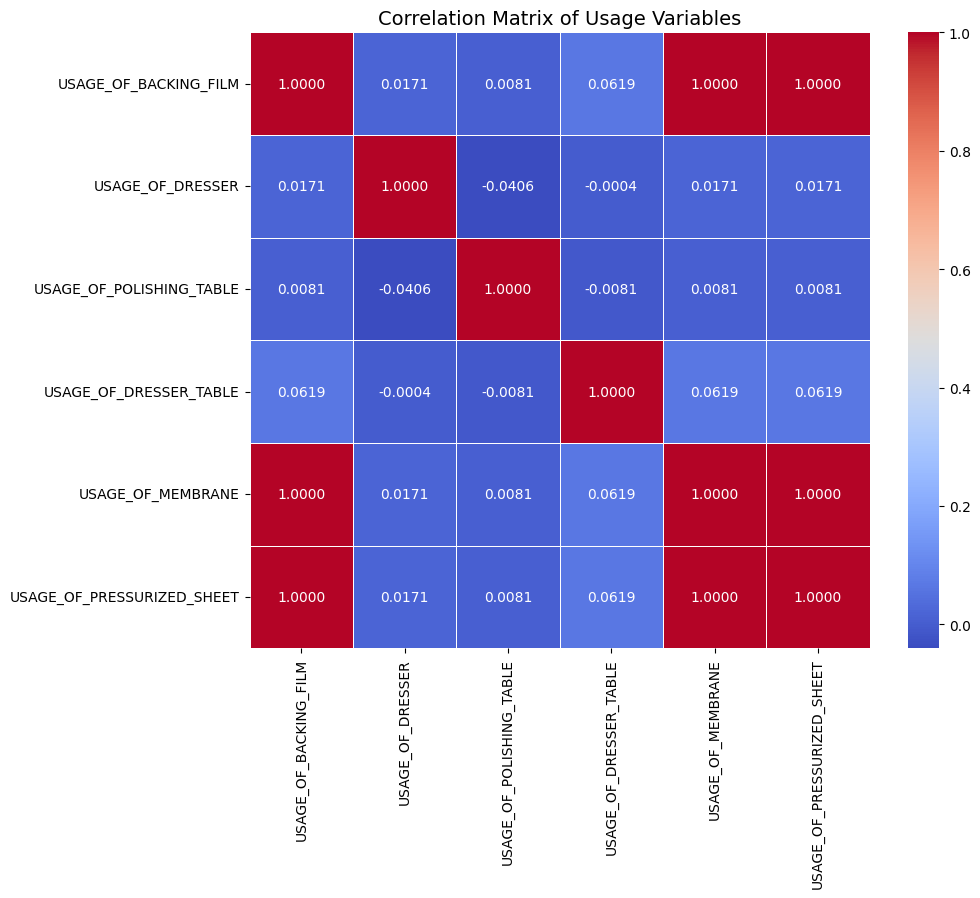

In [5]:
if not big_df.empty and 'TIMESTAMP' in big_df.columns:
    print(f"\n正在針對所有資料點進行作圖 (Scatter Plot)...")
    plot_data = big_df.copy()
    plot_data['TIMESTAMP'] = pd.to_numeric(plot_data['TIMESTAMP'], errors='coerce')
    plot_data = plot_data.sort_values(by='TIMESTAMP')
    exclude_cols = ['WAFER_ID', 'TIMESTAMP', 'CHAMBER', 'STAGE', 'DRESSING_WATER_STATUS']
    all_plot_cols = [col for col in plot_data.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(plot_data[col])]
    
    airbag_cols = [col for col in all_plot_cols if 'AIR_BAG' in col]
    slurry_cols = [col for col in all_plot_cols if 'SLURRY' in col]
    usage_cols = [col for col in all_plot_cols if 'USAGE' in col]
    rotation_cols = [col for col in all_plot_cols if 'ROTATION' in col]
    
    categorized_cols = set(airbag_cols + slurry_cols + usage_cols + rotation_cols)
    other_cols = [col for col in all_plot_cols if col not in categorized_cols]
    
    feature_groups = {
        "Air Bag Variables": airbag_cols,
        "Slurry Variables": slurry_cols,
        "Usage Variables": usage_cols,
        "Rotation Variables": rotation_cols,
        "Other Variables": other_cols
    }
    
    for group_name, cols in feature_groups.items():
        if not cols: continue
        if group_name == "Air Bag Variables": n_cols = 2
        elif group_name == "Slurry Variables": n_cols = 1
        else: n_cols = 3
        n_rows = max(1, int(np.ceil(len(cols) / n_cols)))
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows))
        axes = np.atleast_1d(axes).flatten()
        
        for i, col in enumerate(cols):
            axes[i].plot(plot_data['TIMESTAMP'], plot_data[col], marker='.', linestyle='none', markersize=1, color='teal', alpha=0.3)
            axes[i].set_title(f"{col}", fontsize=10, fontweight='bold')
            axes[i].set_xlabel("TIMESTAMP")
            axes[i].set_ylabel("Value")
            axes[i].grid(True, linestyle='--', alpha=0.6)
            
        for j in range(len(cols), len(axes)):
            fig.delaxes(axes[j])
            
        plt.suptitle(f"{group_name} vs TIMESTAMP", fontsize=14, fontweight='bold')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95], pad=1.5)
        plt.show()
else:
    print("資料集為空或找不到 TIMESTAMP 欄位，無法作圖。")

print("\n正在檢查氣囊壓力變數之間的相關性 (共線性檢查)...")
pressure_cols_to_check = [
    'MAIN_OUTER_AIR_BAG_PRESSURE',
    'CENTER_AIR_BAG_PRESSURE',
    'RIPPLE_AIR_BAG_PRESSURE',
    'EDGE_AIR_BAG_PRESSURE'
]
existing_pressure_cols = [col for col in pressure_cols_to_check if col in big_df.columns]

if len(existing_pressure_cols) > 1:
    pressure_corr_matrix = big_df[existing_pressure_cols].corr()
    print("氣囊壓力相關係數矩陣:")
    print(pressure_corr_matrix)
    plt.figure(figsize=(8, 6))
    sns.heatmap(pressure_corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", linewidths=.5)
    plt.title('Correlation Matrix of Air Bag Pressures', fontsize=14)
    plt.show()

print("\n正在檢查耗材使用量 (USAGE) 變數之間的相關性 (共線性檢查)...")
usage_cols_to_check = [col for col in big_df.columns if 'USAGE' in col]
if len(usage_cols_to_check) > 1:
    usage_corr_matrix = big_df[usage_cols_to_check].corr()
    print("耗材使用量相關係數矩陣:")
    print(usage_corr_matrix)
    plt.figure(figsize=(10, 8))
    sns.heatmap(usage_corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", linewidths=.5)
    plt.title('Correlation Matrix of Usage Variables', fontsize=14)
    plt.show()



接著檢查各欄位和y的相關係數，篩選出那些變數是和y有高度的"線性"關係，可以初步判斷哪些特徵對於MRR具影響力。
由於Chamber為One-Hot變數，所以不考慮，接下來Wafer_Rotation、Slurry_flow_stage_rotation、stage_rota，則後續建立非線性模型時可以回來對應比較看看

正在計算各特徵與目標變數 (AVG_REMOVAL_RATE) 的相關係數...
n各變數與 AVG_REMOVAL_RATE 的相關係數 (由高到低):
USAGE_OF_DRESSER_TABLE          0.112558
TIMESTAMP                       0.111903
USAGE_OF_BACKING_FILM           0.075165
USAGE_OF_MEMBRANE               0.075165
USAGE_OF_PRESSURIZED_SHEET      0.075165
DRESSING_WATER_STATUS           0.043318
USAGE_OF_DRESSER               -0.031326
HEAD_ROTATION                  -0.096955
USAGE_OF_POLISHING_TABLE       -0.119994
SLURRY_FLOW_LINE_B             -0.504789
SLURRY_FLOW_LINE_A             -0.565032
RIPPLE_AIR_BAG_PRESSURE        -0.617209
MAIN_OUTER_AIR_BAG_PRESSURE    -0.617449
STAGE_ROTATION                 -0.625546
CENTER_AIR_BAG_PRESSURE        -0.631439
PRESSURIZED_CHAMBER_PRESSURE   -0.632769
EDGE_AIR_BAG_PRESSURE          -0.635312
RETAINER_RING_PRESSURE         -0.642480
SLURRY_FLOW_LINE_C             -0.665851
WAFER_ROTATION                 -0.721357
CHAMBER                        -0.961270
Name: AVG_REMOVAL_RATE, dtype: float64


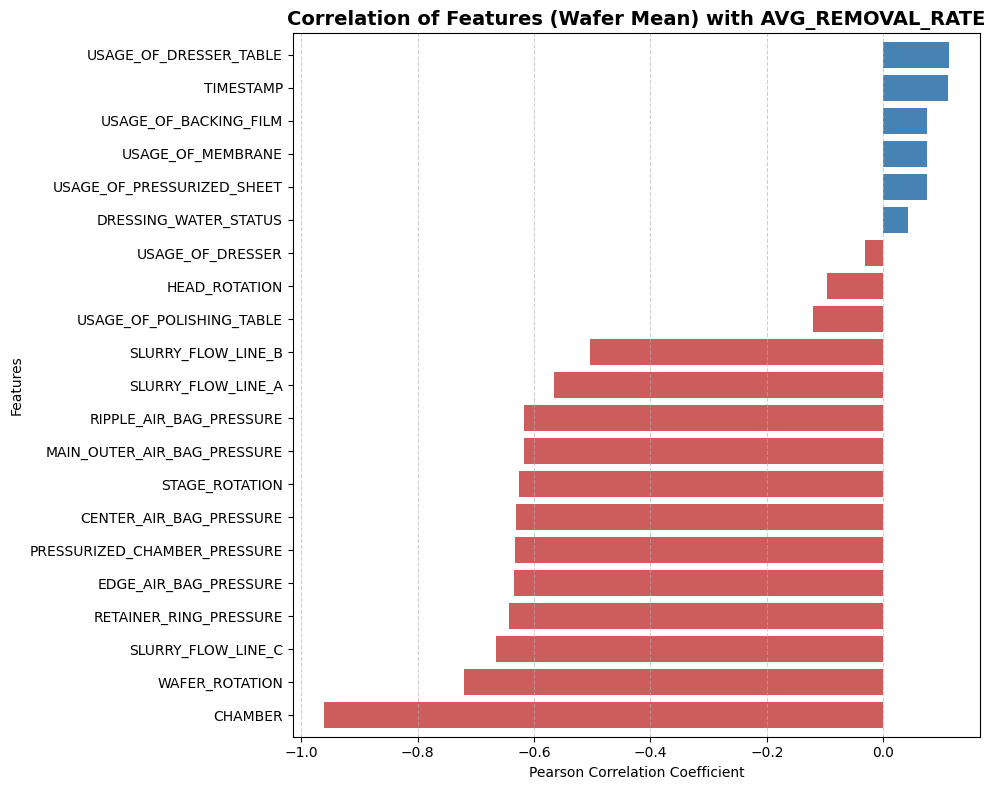

In [6]:
print("正在計算各特徵與目標變數 (AVG_REMOVAL_RATE) 的相關係數...")
mrr_target = y_cleaned_df['AVG_REMOVAL_RATE'] if 'y_cleaned_df' in locals() else y_df['AVG_REMOVAL_RATE']
# 以 WAFER_ID 為單位取平均，用於初步相關性分析
eda_grouped = big_df.groupby('WAFER_ID').mean(numeric_only=True)
eda_joined = eda_grouped.join(mrr_target, how='inner')

# 計算與目標變數的相關係數並排序
corr_with_y = eda_joined.corr()['AVG_REMOVAL_RATE'].drop('AVG_REMOVAL_RATE').sort_values(ascending=True)

print("n各變數與 AVG_REMOVAL_RATE 的相關係數 (由高到低):")
print(corr_with_y.sort_values(ascending=False))
# 繪製相關係數水平長條圖\n",
plt.figure(figsize=(10, 8))
colors = ['indianred' if val < 0 else 'steelblue' for val in corr_with_y]
corr_with_y.plot(kind='barh', color=colors, width=0.8)
plt.title('Correlation of Features (Wafer Mean) with AVG_REMOVAL_RATE', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 2.4 (30%) 製程效能預測模型建構
此部分將進行以下特徵與建模工程：
- **特徵工程**:
1. 定義製程階段: `研磨期`:Wafer跟Stage同時有在轉，`浸泡期` :壓力有作用但Wafer跟Stage同時沒轉 `閒置期` :壓力和轉速都沒作用，並萃取期階段持續時間為特徵。
2. 針對`耗材類`變數，對其做min-max轉換，再取`max`作為特徵值。
3. 針對`壓力類`變數，對非0的資料取`平均值`跟`標準差`。
4. 針對`研磨液`變數，取`sum`為特徵代表總流量。
5. 針對`轉速類`變數，head轉速取非零資料的`中位數`跟`標準差`，其他兩個轉速取非零資料的`平均數`跟`標準差`
6. 針對`注水狀態`，取`平均數`代表其製程注水時間比例。
非零資料的平均數跟標準差。
7. NOTE:所有特徵Groupby chamber(判斷特徵跟chamber是有交互作用的)
- **特徵挑選**：剔除不具影響力之變數，包括前面發現的高度共線性之變數，並利用 Tree-based Model 輸出之 Feature Importance 進行關鍵變數篩選。
- **分組建模** :依前面的發現將Stage A & Chamber=1/2/3分類為高速組別，其他則為低速組別，分開訓練模型。
- **訓練與驗證方式**：採用時間序列滑動窗口嵌套交叉驗證 (Nested Time-Series CV) 以貼近真實世界測試狀況，利用CV確認模型狀況後，再利用全部Training data進行超參數搜索，以預測Testing data。
- **模型選擇**：比較決策樹、隨機森林、XGBoost、SVR與神經網路等演算法的效能。

In [7]:
## ====================================================================
## 2.4-1 特徵工程 (Feature Engineering)
## ====================================================================
def extract_physics_features(df):
    df = df.sort_values(by=['WAFER_ID', 'CHAMBER', 'STAGE', 'TIMESTAMP']).copy()
    time_diffs = df['TIMESTAMP'].diff().fillna(0)
    boundary_mask = (df['WAFER_ID'] != df['WAFER_ID'].shift(1)) | \
                    (df['CHAMBER'] != df['CHAMBER'].shift(1)) | \
                    (df['STAGE'] != df['STAGE'].shift(1))
    time_diffs[boundary_mask] = 0
    pressure_active = df['PRESSURIZED_CHAMBER_PRESSURE'] > 0 if 'PRESSURIZED_CHAMBER_PRESSURE' in df.columns else pd.Series(False, index=df.index)
    head_is_rotating = df['HEAD_ROTATION'] > 0.1 if 'HEAD_ROTATION' in df.columns else pd.Series(False, index=df.index)
    wafer_is_rotating = df['WAFER_ROTATION'] > 0.1 if 'WAFER_ROTATION' in df.columns else pd.Series(False, index=df.index)
    stage_is_rotating = df['STAGE_ROTATION'] > 0.1 if 'STAGE_ROTATION' in df.columns else pd.Series(False, index=df.index)
    polishing_rotation_active = wafer_is_rotating & stage_is_rotating
    any_rotation_active = head_is_rotating | wafer_is_rotating | stage_is_rotating
    is_polishing = pressure_active & polishing_rotation_active
    df['polishing_duration'] = time_diffs.where(is_polishing, 0)
    df['soaking_duration'] = time_diffs.where(pressure_active & ~polishing_rotation_active, 0)
    df['idle_duration'] = time_diffs.where(~pressure_active & ~any_rotation_active, 0)
    df['spinning_duration'] = time_diffs.where(~pressure_active & any_rotation_active, 0)
    pressure_cols = [col for col in df.columns if 'PRESSURE' in col and not col.startswith('polishing_')]
    for p_col in pressure_cols:
        df[f"polishing_{p_col}"] = df[p_col].where(is_polishing, np.nan)
    return df

def nonzero_mean(x): return x[x > 0.1].mean() if not x[x > 0.1].empty else np.nan
def nonzero_std(x): return x[x > 0.1].std() if not x[x > 0.1].empty else np.nan
def nonzero_median(x): return x[x > 0.1].median() if not x[x > 0.1].empty else np.nan

def rename_cols(df):
    new_cols = []
    for col in df.columns:
        # 因為 STAGE 不展開了，所以 col 裡只有 3 個元素：(變數名, 統計量, CHAMBER)
        var_name, stat_name, chamber = col[0], col[1], str(int(col[2]))
        if hasattr(stat_name, '__name__'): stat_name = stat_name.__name__
        new_cols.append(f"{var_name}_{stat_name}_Ch{chamber}")
    df.columns = new_cols
    return df

def build_features(df_raw, label_path=None, is_train=True, scalers=None):
    cols_to_drop = ['CENTER_AIR_BAG_PRESSURE', 'RIPPLE_AIR_BAG_PRESSURE', 'EDGE_AIR_BAG_PRESSURE']
    df = df_raw.drop(columns=[col for col in cols_to_drop if col in df_raw.columns], errors='ignore')
    df = extract_physics_features(df)
    
    consumable_cols = ['USAGE_OF_DRESSER', 'USAGE_OF_POLISHING_TABLE', 'USAGE_OF_DRESSER_TABLE', 'USAGE_OF_MEMBRANE']
    if is_train:
        scalers = {}
        for col in consumable_cols:
            if col in df.columns:
                scaler = MinMaxScaler()
                df[col] = scaler.fit_transform(df[[col]])
                scalers[col] = scaler
    else:
        for col in consumable_cols:
            if col in df.columns and scalers and col in scalers:
                df[col] = scalers[col].transform(df[[col]])
                
    agg_dict = {'USAGE_OF_DRESSER': ['max'], 'USAGE_OF_POLISHING_TABLE': ['max'], 'USAGE_OF_DRESSER_TABLE': ['max'], 'USAGE_OF_MEMBRANE': ['max'], 'polishing_duration': ['sum'], 'soaking_duration': ['sum'], 'idle_duration': ['sum'], 'spinning_duration': ['sum'], 'PRESSURIZED_CHAMBER_PRESSURE': [nonzero_mean, nonzero_std], 'MAIN_OUTER_AIR_BAG_PRESSURE': [nonzero_mean, nonzero_std], 'RETAINER_RING_PRESSURE': [nonzero_mean, nonzero_std], 'SLURRY_FLOW_LINE_A': ['sum'], 'SLURRY_FLOW_LINE_B': ['sum'], 'SLURRY_FLOW_LINE_C': ['sum'], 'WAFER_ROTATION': [nonzero_mean, nonzero_std], 'STAGE_ROTATION': [nonzero_median, nonzero_std], 'HEAD_ROTATION': [nonzero_mean, nonzero_std], 'DRESSING_WATER_STATUS': ['mean']}
    for p_col in ['PRESSURIZED_CHAMBER_PRESSURE', 'MAIN_OUTER_AIR_BAG_PRESSURE', 'RETAINER_RING_PRESSURE']:
        if f"polishing_{p_col}" in df.columns: agg_dict[f"polishing_{p_col}"] = [np.nanmean, np.nanstd]
        
    # 修正 1：只展開 CHAMBER，讓 STAGE 保留在 Index 裡
    feature_df = df.groupby(['WAFER_ID', 'STAGE', 'CHAMBER']).agg(agg_dict)
    feature_unstacked = rename_cols(feature_df.unstack(level=['CHAMBER']))
    
    if label_path and os.path.exists(label_path):
        y_df = pd.read_csv(label_path)
        # 修正 2：利用 WAFER_ID 和 STAGE 的組合去重與設定索引
        y_df = y_df.drop_duplicates(subset=['WAFER_ID', 'STAGE']).set_index(['WAFER_ID', 'STAGE'])
        final_df = feature_unstacked.join(y_df, how='inner')
    else:
        final_df = feature_unstacked.copy()
        
    # 修正 3：時間起點也要依據 WAFER_ID 和 STAGE 組合計算
    start_time = df.groupby(['WAFER_ID', 'STAGE'])['TIMESTAMP'].min().rename('START_TIMESTAMP')
    final_df = final_df.join(start_time).sort_values('START_TIMESTAMP')
    
    if is_train and 'AVG_REMOVAL_RATE' in final_df.columns:
        final_df = final_df[(final_df['AVG_REMOVAL_RATE'] < 300) & (final_df['AVG_REMOVAL_RATE'] > 10)]
        
    final_df.reset_index(inplace=True)
    return final_df, scalers

print("正在處理訓練集資料...")
final_df, train_scalers = build_features(big_df, LABEL_PATH, is_train=True)
print(f"Training set 特徵工程完成，最終維度: {final_df.shape}")

TEST_DATA_PATH = str(PROJECT_ROOT / 'data' / 'raw' / 'test')
TEST_LABEL_PATH = str(PROJECT_ROOT / 'data' / 'raw' / 'labels' / 'CMP-test-removalrate.csv')

test_files = glob.glob(os.path.join(TEST_DATA_PATH, '*.csv'))
test_big_df = pd.concat([pd.read_csv(f) for f in test_files], ignore_index=True)
test_final_df, _ = build_features(test_big_df, TEST_LABEL_PATH, is_train=False, scalers=train_scalers)
print(f"Test set 特徵工程完成，測試集維度: {test_final_df.shape}")



正在處理訓練集資料...
Training set 特徵工程完成，最終維度: (1977, 184)
Test set 特徵工程完成，測試集維度: (424, 184)



因為後續要建立五種模型進行比較，因此事先建立好共用函數與資料，包括高低速分組、模型驗證架構、模型重要度輸出、模型評估等函數，則後續模型建立只需引入模型套件並設定超參數range即可快速完成整個訓練流程，以達到最大化程式效率及版面占用。


In [ ]:
# ====================================================================
# 4. 建立共用函數與資料準備 (Functions & Data Prep)
# ====================================================================

if 'WAFER_ID' in final_df.columns: final_df = final_df.set_index('WAFER_ID')
if 'START_TIMESTAMP' in final_df.columns: final_df = final_df.sort_values('START_TIMESTAMP').drop(columns=['START_TIMESTAMP'])
else: final_df = final_df.sort_index()

X = final_df.drop(columns=['AVG_REMOVAL_RATE', 'neighbor_feature', 'USAGE_OF_BACKING_FILM'], errors='ignore')

if 'STAGE' in X.columns: 
    X['STAGE'] = X['STAGE'].map({'A': 0, 'B': 1}).fillna(-1)

y = final_df['AVG_REMOVAL_RATE']

high_group_cols = [c for c in X.columns if any(k in c for k in ['_Ch1', '_Ch2', '_Ch3'])]
low_group_cols = [c for c in X.columns if any(k in c for k in ['_Ch4', '_Ch5', '_Ch6'])]
is_high_group = X[high_group_cols].notna().any(axis=1)

drop_from_high_cols = [c for c in X.columns if any(k in c for k in ['_Ch4', '_Ch5', '_Ch6'])]
drop_from_low_cols = [c for c in X.columns if any(k in c for k in ['_Ch1', '_Ch2', '_Ch3'])]

X_high = X[is_high_group].copy().drop(columns=X.columns.intersection(drop_from_high_cols))
y_high = y[is_high_group].copy()
X_low = X[~is_high_group].copy().drop(columns=X.columns.intersection(drop_from_low_cols))
y_low = y[~is_high_group].copy()

imputer_high = SimpleImputer(strategy='constant', fill_value=0)
X_high_filled = imputer_high.fit_transform(X_high)
imputer_low = SimpleImputer(strategy='constant', fill_value=0)
X_low_filled = imputer_low.fit_transform(X_low)

def train_model(estimator, search_spaces, X_data, y_data, group_name, n_iter=50):
    print(f"\n正在為 {group_name} 執行巢狀時間序列交叉驗證...")
    fold_size = len(X_data) // 6
    outer_cv = TimeSeriesSplit(n_splits=5, max_train_size=fold_size * 2)
    search = BayesSearchCV(estimator=estimator, search_spaces=search_spaces, n_iter=n_iter, cv=TimeSeriesSplit(n_splits=3), scoring='neg_mean_squared_error', n_jobs=1, verbose=0, random_state=42)
    stopper = DeltaYStopper(delta=0.01, n_best=15)
    nested_scores = cross_val_score(search, X=X_data, y=y_data, cv=outer_cv, scoring='neg_mean_squared_error', n_jobs=1, fit_params={'callback': stopper})
    print(f"✅ [{group_name}] 各折 MSE 結果:")
    for i, score in enumerate(nested_scores):
        print(f"   Fold {i+1}: {-score:.4f}")
    print(f"   平均 MSE: {-np.mean(nested_scores):.4f}(標準差: {np.std(nested_scores):.4f})")
    search.fit(X_data, y_data, callback=stopper)
    print(f"   最佳參數: {search.best_params_}")
    return search.best_estimator_

def show_importance(model, feature_names, title):
    if hasattr(model, 'feature_importances_'): importances = model.feature_importances_
    else: importances = np.zeros(len(feature_names))
    imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
    print(f"\n【{title} 特徵重要度 Top 10】\n", imp_df.head(10))

def evaluate_model(model_name, model_high, model_low, test_df, refined_high_cols=None, refined_low_cols=None, imputer_high=None, imputer_low=None):
    if test_df is None or len(test_df) == 0: 
        print(f"\n⚠️ 無測試集，跳過評估 {model_name}")
        return None
    print(f"\n🎯 【{model_name} 測試集預測與評估】")
    test_df = test_df.set_index('WAFER_ID') if 'WAFER_ID' in test_df.columns else test_df.copy()
    y_test = test_df['AVG_REMOVAL_RATE'] if 'AVG_REMOVAL_RATE' in test_df.columns else None
    X_test = test_df.drop(columns=['AVG_REMOVAL_RATE', 'START_TIMESTAMP'], errors='ignore')
    
    if 'STAGE' in X_test.columns:
        X_test['STAGE'] = X_test['STAGE'].map({'A': 0, 'B': 1}).fillna(-1)
        
    for c in set(X.columns) - set(X_test.columns): X_test[c] = 0
    X_test = X_test[X.columns]
    is_test_high = X_test[high_group_cols].notna().any(axis=1)
    y_pred = pd.Series(index=X_test.index, dtype=float)
    imp_high = imputer_high if imputer_high is not None else globals()['imputer_high']
    imp_low = imputer_low if imputer_low is not None else globals()['imputer_low']
    if is_test_high.any():
        X_test_h = X_test[is_test_high].drop(columns=X_test.columns.intersection(drop_from_high_cols))
        if refined_high_cols is not None: X_test_h = X_test_h[refined_high_cols]
        y_pred[is_test_high] = model_high.predict(imp_high.transform(X_test_h))
    if (~is_test_high).any():
        X_test_l = X_test[~is_test_high].drop(columns=X_test.columns.intersection(drop_from_low_cols))
        if refined_low_cols is not None: X_test_l = X_test_l[refined_low_cols]
        y_pred[~is_test_high] = model_low.predict(imp_low.transform(X_test_l))
    if y_test is not None:
        y_vals, p_vals = y_test.values, y_pred.values
        print(f"   Validation MSE: {mean_squared_error(y_vals, p_vals):.2f}")
        print(f"   Validation MAPE: {np.mean(np.abs((y_vals - p_vals) / y_vals)) * 100:.2f}%")
        print(f"   Validation R2: {r2_score(y_test, y_pred):.4f}")
        plt.figure(figsize=(7, 5))
        plt.scatter(y_test[is_test_high], y_pred[is_test_high], alpha=0.7, color='red', label='High Group')
        plt.scatter(y_test[~is_test_high], y_pred[~is_test_high], alpha=0.7, color='blue', label='Low Group')
        min_val, max_val = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
        plt.xlabel("Actual Rate")
        plt.ylabel("Predicted Rate")
        plt.title(f"{model_name} Validation")
        plt.legend()
        plt.show()
    return y_pred


### ====================================================================
###  模型訓練與評估 (Modeling & Evaluation)
### ====================================================================

###  決策樹 (Decision Tree)
利用單一樹狀結構建立預測模型，具備高度可解釋性。並使用Bayesian SearchCV搭配「滑動窗口巢狀交叉驗證」來篩選最佳參數:
- **最大樹深度:4~10**
- **切分節點最小所需樣本數:10~60**
- **最終葉子最小樣本數:2~10**


🌟 決策樹 (Decision Tree) 模型訓練

正在為 DT_High_Group 執行巢狀時間序列交叉驗證...
✅ [DT_High_Group] 各折 MSE 結果:
   Fold 1: 12.6978
   Fold 2: 15.2015
   Fold 3: 8.1526
   Fold 4: 41.7602
   Fold 5: 26.8512
   平均 MSE: 20.9326(標準差: 12.1062)
   最佳參數: OrderedDict([('max_depth', 8), ('min_samples_leaf', 8), ('min_samples_split', 28)])

正在為 DT_Low_Group 執行巢狀時間序列交叉驗證...
✅ [DT_Low_Group] 各折 MSE 結果:
   Fold 1: 108.6891
   Fold 2: 38.2865
   Fold 3: 140.0577
   Fold 4: 32.3430
   Fold 5: 38.6480
   平均 MSE: 71.6049(標準差: 44.2692)
   最佳參數: OrderedDict([('max_depth', 8), ('min_samples_leaf', 10), ('min_samples_split', 18)])

【DT High Group 特徵重要度 Top 10】
                            Feature  Importance
9   USAGE_OF_DRESSER_TABLE_max_Ch3    0.346308
8   USAGE_OF_DRESSER_TABLE_max_Ch2    0.292790
11       USAGE_OF_MEMBRANE_max_Ch2    0.080991
3         USAGE_OF_DRESSER_max_Ch3    0.051493
1         USAGE_OF_DRESSER_max_Ch1    0.038548
2         USAGE_OF_DRESSER_max_Ch2    0.034068
12       USAGE_OF_MEMBRANE_max_Ch3    0.03

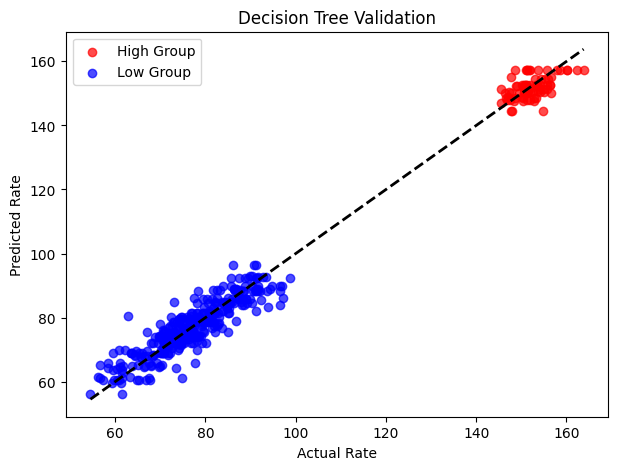

In [ ]:
print("\n" + "=" * 40)
print("🌟 決策樹 (Decision Tree) 模型訓練")
print("=" * 40)
dt_search_space = {'max_depth': Integer(4, 10), 'min_samples_split': Integer(10, 60), 'min_samples_leaf': Integer(2, 20)}
model_dt_high = train_model(DecisionTreeRegressor(random_state=42), dt_search_space, X_high_filled, y_high, "DT_High_Group", n_iter=50)
model_dt_low = train_model(DecisionTreeRegressor(random_state=42), dt_search_space, X_low_filled, y_low, "DT_Low_Group", n_iter=50)
show_importance(model_dt_high, X_high.columns, "DT High Group")
y_pred_dt = evaluate_model("Decision Tree", model_dt_high, model_dt_low, test_final_df)


###  隨機森林 (Random Forest)
透過 Bagging 概念結合多棵決策樹，能有效降低模型變異 (Variance)，減少單一決策樹容易 Overfitting 的問題。超參數選擇範圍:
- **平行樹的數量:50~500**
- **最大深度:5~30**
- **葉片最小樣本:1~8**


🌟 隨機森林 (Random Forest) 模型訓練

正在為 RF_High_Group 執行巢狀時間序列交叉驗證...
✅ [RF_High_Group] 各折 MSE 結果:
   Fold 1: 12.0633
   Fold 2: 9.6480
   Fold 3: 8.1054
   Fold 4: 31.0112
   Fold 5: 26.6799
   平均 MSE: 17.5016(標準差: 9.4477)
   最佳參數: OrderedDict([('max_depth', 50), ('min_samples_leaf', 15), ('n_estimators', 10)])

正在為 RF_Low_Group 執行巢狀時間序列交叉驗證...
✅ [RF_Low_Group] 各折 MSE 結果:
   Fold 1: 101.7281
   Fold 2: 45.8403
   Fold 3: 157.9592
   Fold 4: 23.7930
   Fold 5: 18.1025
   平均 MSE: 69.4846(標準差: 53.2058)
   最佳參數: OrderedDict([('max_depth', 48), ('min_samples_leaf', 1), ('n_estimators', 414)])

【RF High Group 特徵重要度 Top 10】
                              Feature  Importance
7     USAGE_OF_DRESSER_TABLE_max_Ch1    0.252002
9     USAGE_OF_DRESSER_TABLE_max_Ch3    0.239938
8     USAGE_OF_DRESSER_TABLE_max_Ch2    0.160551
1           USAGE_OF_DRESSER_max_Ch1    0.068515
11         USAGE_OF_MEMBRANE_max_Ch2    0.040313
2           USAGE_OF_DRESSER_max_Ch2    0.032371
12         USAGE_OF_MEMBRANE_max_Ch3

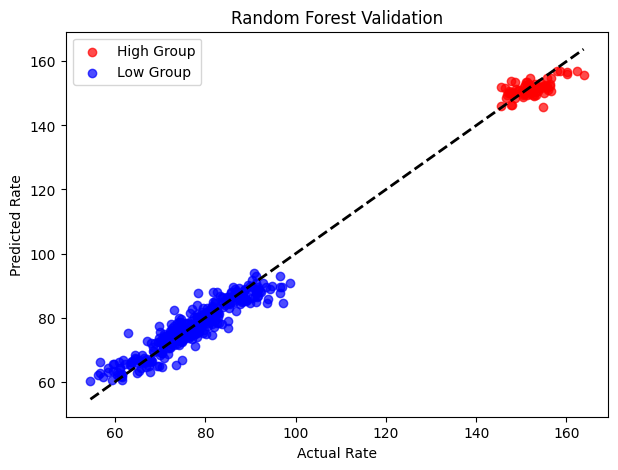

In [19]:
print("\n" + "=" * 40)
print("🌟 隨機森林 (Random Forest) 模型訓練")
print("=" * 40)
rf_param_grid = {'n_estimators': Integer(10, 500), 'max_depth': Integer(5, 50), 'min_samples_leaf': Integer(1,15)}
model_rf_high = train_model(RandomForestRegressor(random_state=42, n_jobs=-1), rf_param_grid, X_high_filled, y_high, "RF_High_Group")
model_rf_low = train_model(RandomForestRegressor(random_state=42, n_jobs=-1), rf_param_grid, X_low_filled, y_low, "RF_Low_Group")
show_importance(model_rf_high, X_high.columns, "RF High Group")
y_pred_rf = evaluate_model("Random Forest", model_rf_high, model_rf_low, test_final_df)


###  GBM
基於梯度提升樹 (Gradient Boosting) 架構，並加入了正則化 (Regularization) 懲罰項，對於雜訊與極端值有良好的抵抗力。超參數選擇:
- **迭帶樹數量:100~1000**
- **學習率:0.01~0.1**
- **最大深度:3~6**
- **每次抽樣比例:0.6~1**
- **每次建樹使用欄位比例:0.7~0.9**


🌟 XGBoost 模型訓練

正在為 XGB_High_Group 執行巢狀時間序列交叉驗證...
✅ [XGB_High_Group] 各折 MSE 結果:
   Fold 1: 11.8878
   Fold 2: 7.7266
   Fold 3: 8.5657
   Fold 4: 39.1403
   Fold 5: 27.7575
   平均 MSE: 19.0156(標準差: 12.4006)
   最佳參數: OrderedDict([('colsample_bytree', 0.5), ('learning_rate', 0.01), ('max_depth', 3), ('min_child_weight', 9), ('n_estimators', 840), ('reg_alpha', 0.1), ('reg_lambda', 1.0), ('subsample', 0.6)])

正在為 XGB_Low_Group 執行巢狀時間序列交叉驗證...
✅ [XGB_Low_Group] 各折 MSE 結果:
   Fold 1: 73.3219
   Fold 2: 58.2787
   Fold 3: 80.0066
   Fold 4: 24.0164
   Fold 5: 25.3573
   平均 MSE: 52.1962(標準差: 23.5421)
   最佳參數: OrderedDict([('colsample_bytree', 0.5), ('learning_rate', 0.05886152397540058), ('max_depth', 3), ('min_child_weight', 9), ('n_estimators', 625), ('reg_alpha', 0.1), ('reg_lambda', 1.0), ('subsample', 0.6)])

【XGB High Group 特徵重要度 Top 10】
                            Feature  Importance
8   USAGE_OF_DRESSER_TABLE_max_Ch2    0.038649
7   USAGE_OF_DRESSER_TABLE_max_Ch1    0.035627
9   USAG

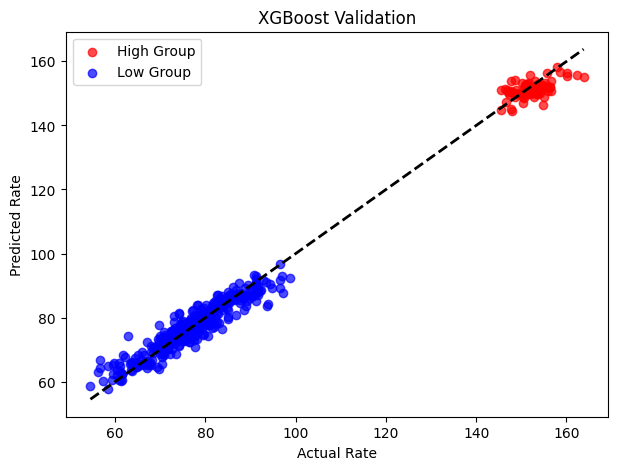

In [20]:
print("\n" + "=" * 40)
print("🌟 XGBoost 模型訓練")
print("=" * 40)
xgb_search_space = {
    'n_estimators': Integer(100, 1000),
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
    'max_depth': Integer(3, 6), 
    'min_child_weight': Categorical([1, 3, 5, 7, 9]),
    'subsample': Real(0.6, 1.0),
    'colsample_bytree': Categorical([0.5, 0.6, 0.7, 0.8, 0.9]),
    'reg_alpha': Categorical([0.1]),
    'reg_lambda': Categorical([1.0])
}
model_xgb_high = train_model(XGBRegressor(random_state=42, objective='reg:squarederror'), xgb_search_space, X_high_filled, y_high, "XGB_High_Group", n_iter=50)
model_xgb_low = train_model(XGBRegressor(random_state=42, objective='reg:squarederror'), xgb_search_space, X_low_filled, y_low, "XGB_Low_Group", n_iter=50)
show_importance(model_xgb_high, X_high.columns, "XGB High Group")
y_pred_xgb = evaluate_model("XGBoost", model_xgb_high, model_xgb_low, test_final_df)


###  支持向量迴歸 (SVR)
利用核函數 (Kernel Trick) 處理非線性問題，對於特徵空間的高維映射有良好的表現。這裡透過 Pipeline 結合 StandardScaler 來進行特徵標準化，以確保模型收斂與距離計算的準確性。超參數選擇:
- **逞罰項:1~100**
- **容忍誤差:0.05~3**
- **高斯核參數:auto/scale**


🌟 支持向量迴歸 (SVR) 模型訓練

正在為 SVR_High_Group 執行巢狀時間序列交叉驗證...
✅ [SVR_High_Group] 各折 MSE 結果:
   Fold 1: 10.7391
   Fold 2: 8.7406
   Fold 3: 7.1693
   Fold 4: 33.7040
   Fold 5: 25.4339
   平均 MSE: 17.1574(標準差: 10.5270)
   最佳參數: OrderedDict([('svr__C', 6.641332059502943), ('svr__epsilon', 0.48874002237836567), ('svr__gamma', 'auto')])

正在為 SVR_Low_Group 執行巢狀時間序列交叉驗證...
✅ [SVR_Low_Group] 各折 MSE 結果:
   Fold 1: 33.9328
   Fold 2: 46.9167
   Fold 3: 27.6507
   Fold 4: 38.2775
   Fold 5: 54.7328
   平均 MSE: 40.3021(標準差: 9.5575)
   最佳參數: OrderedDict([('svr__C', 100.0), ('svr__epsilon', 3.0), ('svr__gamma', 'auto')])

🎯 【SVR 測試集預測與評估】
   Validation MSE: 19.55
   Validation MAPE: 4.07%
   Validation R2: 0.9776


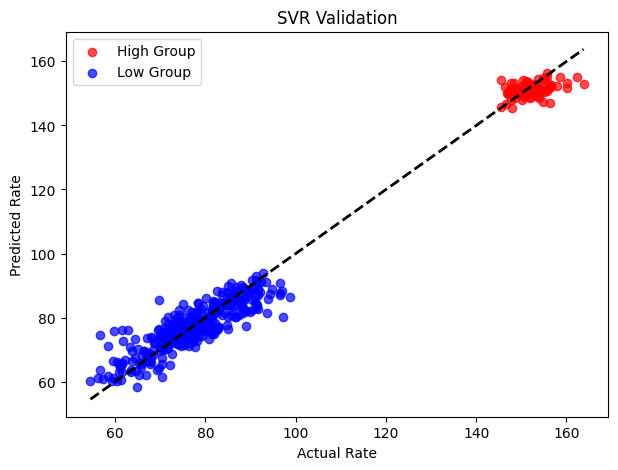

In [10]:
print("\n" + "=" * 40)
print("🌟 支持向量迴歸 (SVR) 模型訓練")
print("=" * 40)
svr_search_space = {'svr__C': Real(1, 100), 'svr__epsilon': Real(0.05, 3), 'svr__gamma': ['scale', 'auto'] }
pipeline_svr = Pipeline([('scaler', StandardScaler()), ('svr', SVR(kernel='rbf'))])
model_svr_high = train_model(pipeline_svr, svr_search_space, X_high_filled, y_high, "SVR_High_Group", n_iter=50)
model_svr_low = train_model(pipeline_svr, svr_search_space, X_low_filled, y_low, "SVR_Low_Group", n_iter=50)
y_pred_svr = evaluate_model("SVR", model_svr_high, model_svr_low, test_final_df)


###  神經網路 (Neural Network)
使用多層感知器 (MLP) 進行迴歸預測。神經網路對特徵的尺度非常敏感，因此這裡結合 `Pipeline` 與 `StandardScaler` 來確保每一折的資料都能正確標準化，並設定 Early Stopping 以防止過擬合。超參數選擇:
- **隱藏層:(64,32)**
- **alpha:0.1**
- **batch_size:16/32/64**
- **優化器:Adam**
- **激活函數:Relu**
- **學習率:0.0001/0.1**


🌟 神經網路 (Neural Network) 模型訓練

正在為 MLP_High_Group 執行巢狀時間序列交叉驗證...
✅ [MLP_High_Group] 各折 MSE 結果:
   Fold 1: 962.5696
   Fold 2: 200.0320
   Fold 3: 544.0132
   Fold 4: 5710.5112
   Fold 5: 313.1051
   平均 MSE: 1546.0462(標準差: 2098.5320)
   最佳參數: OrderedDict([('mlp__alpha', 0.003579800553663253), ('mlp__batch_size', 16), ('mlp__learning_rate_init', 0.1)])

正在為 MLP_Low_Group 執行巢狀時間序列交叉驗證...
✅ [MLP_Low_Group] 各折 MSE 結果:
   Fold 1: 258.5066
   Fold 2: 102782.3181
   Fold 3: 122.0841
   Fold 4: 248.2964
   Fold 5: 126.6868
   平均 MSE: 20707.5784(標準差: 41037.4106)
   最佳參數: OrderedDict([('mlp__alpha', 0.00011218005356957236), ('mlp__batch_size', 32), ('mlp__learning_rate_init', 0.09394088133867842)])

🎯 【Neural Network 測試集預測與評估】
   Validation MSE: 80.41
   Validation MAPE: 6.28%
   Validation R2: 0.9080


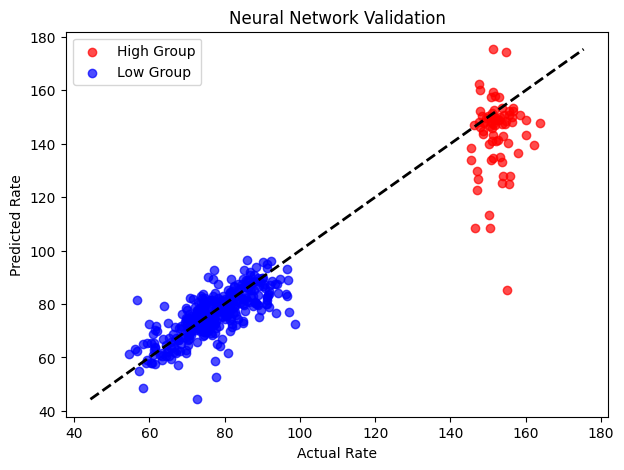

In [17]:
print("\n" + "=" * 40)
print("🌟 神經網路 (Neural Network) 模型訓練")
print("=" * 40)

mlp_param_grid = {
    'mlp__batch_size': Categorical([16, 32, 64]), 
    'mlp__alpha': Real(1e-4, 1e-1, prior='log-uniform'),
    'mlp__learning_rate_init': Real(1e-4, 1e-1, prior='log-uniform')
}

pipeline_mlp = Pipeline([
    ('scaler', StandardScaler()), 
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(64, 32), 
        solver='adam',
        activation='relu',
        max_iter=1000, 
        early_stopping=True, 
        random_state=42
    ))
])

model_mlp_high = train_model(pipeline_mlp, mlp_param_grid, X_high_filled, y_high, "MLP_High_Group")
model_mlp_low = train_model(pipeline_mlp, mlp_param_grid, X_low_filled, y_low, "MLP_Low_Group")
y_pred_mlp = evaluate_model("Neural Network", model_mlp_high, model_mlp_low, test_final_df)

訓練結果發現擬合的非常糟，推測由於NN需要大量資料來訓練，而高低速分組讓高速組資料變太少，因此再訓練一個不分組的NN模型，看看成效會不會比較好。


🌟 神經網路 (Neural Network) 全資料不分組模型訓練

正在為 MLP_All_Data 執行巢狀時間序列交叉驗證...
✅ [MLP_All_Data] 各折 MSE 結果:
   Fold 1: 174.7334
   Fold 2: 499.0967
   Fold 3: 67.7420
   Fold 4: 92.8205
   Fold 5: 67.3084
   平均 MSE: 180.3402(標準差: 164.1654)
   最佳參數: OrderedDict([('mlp__alpha', 0.00011840472016770211), ('mlp__batch_size', 32), ('mlp__learning_rate_init', 0.0530671826040212)])

🎯 【Neural Network (All Data) 測試集預測與評估】
   Validation MSE: 24.40
   Validation MAPE: 4.52%
   Validation R2: 0.9721


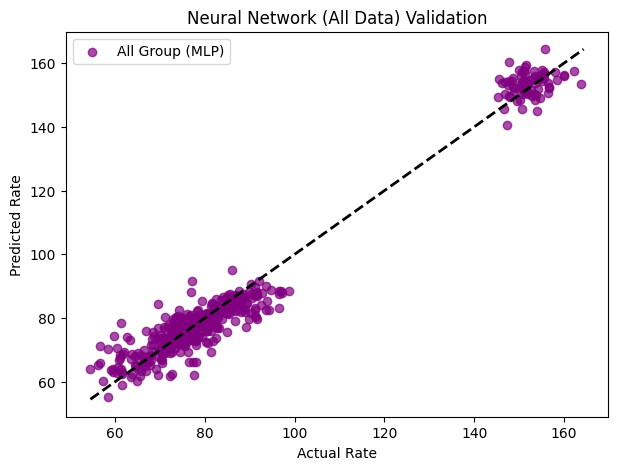

In [18]:
print("\n" + "=" * 40)
print("🌟 神經網路 (Neural Network) 全資料不分組模型訓練")
print("=" * 40)

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from skopt.space import Real, Categorical
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

imputer_all = SimpleImputer(strategy='constant', fill_value=0)
X_filled_all = imputer_all.fit_transform(X)

mlp_param_grid_all = {
    'mlp__batch_size': Categorical([16, 32, 64]), 
    'mlp__alpha': Real(1e-4, 1e-1, prior='log-uniform'),
    'mlp__learning_rate_init': Real(1e-4, 1e-1, prior='log-uniform')
}

pipeline_mlp_all = Pipeline([
    ('scaler', StandardScaler()), 
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(128, 64), 
        solver='adam',
        activation='relu',
        max_iter=1000, 
        early_stopping=True, 
        random_state=42
    ))
])

model_mlp_all = train_model(
    pipeline_mlp_all, 
    mlp_param_grid_all, 
    X_filled_all, 
    y, 
    "MLP_All_Data"
)

if 'test_final_df' in globals() and len(test_final_df) > 0:
    print(f"\n🎯 【Neural Network (All Data) 測試集預測與評估】")
    
    test_df_all = test_final_df.set_index('WAFER_ID') if 'WAFER_ID' in test_final_df.columns else test_final_df.copy()
    y_test_all = test_df_all['AVG_REMOVAL_RATE']
    X_test_all = test_df_all.drop(columns=['AVG_REMOVAL_RATE', 'START_TIMESTAMP'], errors='ignore')
    
    if 'STAGE' in X_test_all.columns:
        X_test_all['STAGE'] = X_test_all['STAGE'].map({'A': 0, 'B': 1}).fillna(-1)
        

    for c in set(X.columns) - set(X_test_all.columns): 
        X_test_all[c] = 0
    X_test_all = X_test_all[X.columns]
    
    X_test_filled_all = imputer_all.transform(X_test_all)
    y_pred_all = model_mlp_all.predict(X_test_filled_all)

    y_vals = y_test_all.values
    print(f"   Validation MSE: {mean_squared_error(y_vals, y_pred_all):.2f}")
    print(f"   Validation MAPE: {np.mean(np.abs((y_vals - y_pred_all) / y_vals)) * 100:.2f}%")
    print(f"   Validation R2: {r2_score(y_vals, y_pred_all):.4f}")
    
    plt.figure(figsize=(7, 5))
    plt.scatter(y_vals, y_pred_all, alpha=0.7, color='purple', label='All Group (MLP)')
    min_val, max_val = min(y_vals.min(), y_pred_all.min()), max(y_vals.max(), y_pred_all.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
    plt.xlabel("Actual Rate")
    plt.ylabel("Predicted Rate")
    plt.title("Neural Network (All Data) Validation")
    plt.legend()
    plt.show()


顯而易見，不採用分組的NN模型效能遠好於分組下的效能，這驗證了我們先前的假設:因為切分資料而造成需要大量訓練資料的NN模型訓練不起來。

###  GBM 模型優化 (Refinement)
由於GBDM是表現最好的模型，因此這邊再進行特徵篩選重訓，
根據前面訓練出的 GBM 模型所得到的特徵重要性，我們可以進行自動化的特徵篩選。這裡我們選出累積重要性貢獻達到 80% 的關鍵特徵，並用這些特徵重新訓練一個更精簡、更有效率的模型。這個過程有助於：
- **降低複雜度**：減少模型需要處理的特徵數量。
- **提升預測速度**：特徵越少，預測越快。
- **可能提升效能**：移除雜訊特徵有時能改善模型的泛化能力。

【正在進行 XGBoost 特徵篩選與模型優化 (Refinement)】

[XGB_High_Group] 特徵縮減: 91 -> 41 個關鍵特徵 (保留前 80% 累積重要度)
[XGB_High_Group] 正在使用關鍵特徵重新訓練...

正在為 XGB_High_Group_Refined 執行巢狀時間序列交叉驗證...
✅ [XGB_High_Group_Refined] 各折 MSE 結果:
   Fold 1: 12.6582
   Fold 2: 8.9273
   Fold 3: 8.3145
   Fold 4: 45.7932
   Fold 5: 25.3415
   平均 MSE: 20.2070(標準差: 14.1892)
   最佳參數: OrderedDict([('colsample_bytree', 0.9), ('learning_rate', 0.03464816682351403), ('max_depth', 6), ('min_child_weight', 3), ('n_estimators', 902), ('reg_alpha', 0.1), ('reg_lambda', 1.0), ('subsample', 0.899929997425254)])

[XGB_Low_Group] 特徵縮減: 91 -> 26 個關鍵特徵 (保留前 80% 累積重要度)
[XGB_Low_Group] 正在使用關鍵特徵重新訓練...

正在為 XGB_Low_Group_Refined 執行巢狀時間序列交叉驗證...
✅ [XGB_Low_Group_Refined] 各折 MSE 結果:
   Fold 1: 81.4571
   Fold 2: 53.9438
   Fold 3: 106.0404
   Fold 4: 22.5114
   Fold 5: 22.8269
   平均 MSE: 57.3559(標準差: 32.7692)
   最佳參數: OrderedDict([('colsample_bytree', 0.9), ('learning_rate', 0.0690080009431382), ('max_depth', 3), ('min_child_weight', 5), ('n_estim

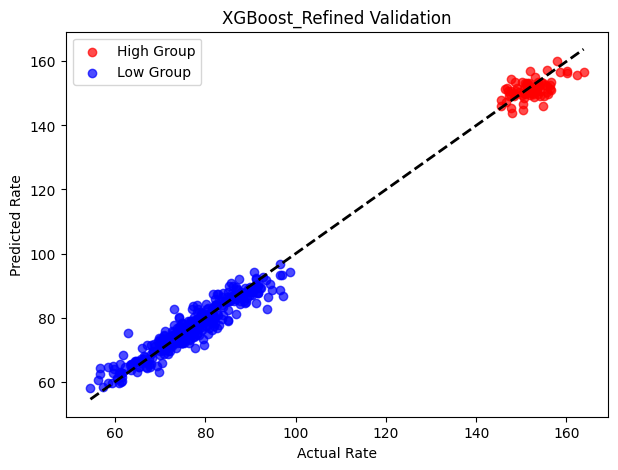

In [13]:
print("【正在進行 XGBoost 特徵篩選與模型優化 (Refinement)】")

def refine_model(base_model, estimator, search_spaces, X_df, y, group_name, cumulative_threshold=0.80):
    # 1. 取得特徵重要度並排序
    importances = base_model.feature_importances_
    imp_df = pd.DataFrame({'Feature': X_df.columns, 'Importance': importances})
    imp_df = imp_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
    
    # 2. 計算累積重要度
    imp_df['Cumulative_Importance'] = imp_df['Importance'].cumsum()
    
    # 3. 找出剛好跨越累積門檻 (預設 80%) 的特徵索引位置
    threshold_idx = imp_df[imp_df['Cumulative_Importance'] >= cumulative_threshold].index.min()
    
    if pd.isna(threshold_idx):
        threshold_idx = len(imp_df) - 1
        
    # 4. 選出累積達到 80% 資訊量的所有特徵 (包含剛好跨過門檻的那一個)
    selected_cols = imp_df.loc[:threshold_idx, 'Feature'].values
    
    print(f"\n[{group_name}] 特徵縮減: {len(X_df.columns)} -> {len(selected_cols)} 個關鍵特徵 (保留前 {cumulative_threshold*100:.0f}% 累積重要度)")
    
    # 重新準備資料 (只保留關鍵特徵)
    X_selected = X_df[selected_cols]
    imputer_refined = SimpleImputer(strategy='constant', fill_value=0)
    X_selected_filled = imputer_refined.fit_transform(X_selected)
    
    # 重新訓練模型 (使用 notebook 中的 train_model，並傳入 estimator 和 search_spaces)
    print(f"[{group_name}] 正在使用關鍵特徵重新訓練...")
    refined_model = train_model(estimator, search_spaces, X_selected_filled, y, f"{group_name}_Refined", n_iter=50)
    
    return refined_model, selected_cols, imputer_refined

# 準備 XGBoost 的 estimator 和 search_spaces
xgb_estimator = XGBRegressor(random_state=42, objective='reg:squarederror')

# 優化 High Group 模型 (使用已訓練好的 model_xgb_high 來取得特徵重要性)
model_xgb_high_opt, cols_high_opt, imputer_high_opt = refine_model(model_xgb_high, xgb_estimator, xgb_search_space, X_high, y_high, "XGB_High_Group")

# 優化 Low Group 模型
model_xgb_low_opt, cols_low_opt, imputer_low_opt = refine_model(model_xgb_low, xgb_estimator, xgb_search_space, X_low, y_low, "XGB_Low_Group")

# ==========================================
#  評估優化後的 XGBoost 模型
# ==========================================
print("-" * 30)
print("【評估優化後的 XGBoost 模型】")
y_pred_xgb_opt = evaluate_model("XGBoost_Refined", model_xgb_high_opt, model_xgb_low_opt, test_final_df, 
                                refined_high_cols=cols_high_opt, refined_low_cols=cols_low_opt,
                                imputer_high=imputer_high_opt, imputer_low=imputer_low_opt)


📊 各模型 Validation MSE 比較表 (數值越低越好)：
--------------------------------------------------
                           Model  Validation MSE
Optimized GBM (Feature Selected)            9.19
         Random Forest (Grouped)           10.15
         Decision Tree (Grouped)           16.12
                   SVR (Grouped)           19.55
       Neural Network (All Data)           24.40
--------------------------------------------------


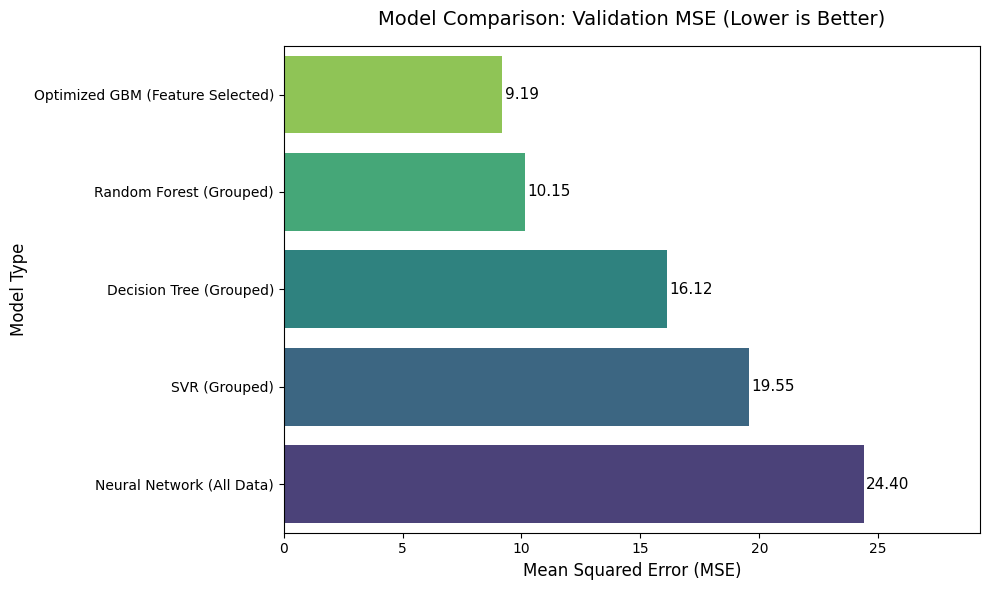

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================================
# 🌟 模型 Validation MSE 總整理 (Model Comparison)
# ====================================================================

# 💡 請將下方的 None 替換為您本地端實際跑出來的 Validation MSE 數值
results_dict = {
    'Model': [
        'Decision Tree (Grouped)', 
        'Random Forest (Grouped)', 
        'Optimized GBM (Feature Selected)', 
        'SVR (Grouped)', 
        'Neural Network (All Data)'
    ],
    'Validation MSE': [
        16.12,          # 稍早提供的 DT 數據
        10.15,           # 替換為您的 Random Forest MSE
        9.19,           # 替換為您的 Optimized GBM MSE
        19.55,           # 替換為您的 SVR MSE
        24.4            # 替換為您的不分組 NN MSE
    ]
}

# 建立 DataFrame 並移除尚未填寫數值的模型 (方便您分批填寫)
df_results = pd.DataFrame(results_dict)
df_results = df_results.dropna().sort_values(by='Validation MSE', ascending=True)

# 1. 印出文字比較表
print("📊 各模型 Validation MSE 比較表 (數值越低越好)：")
print("-" * 50)
print(df_results.to_string(index=False))
print("-" * 50)

# 2. 繪製橫向長條圖進行視覺化
plt.figure(figsize=(10, 6))
# 根據 MSE 大小給予顏色深淺 (越小的越綠/深，越大的越黃/淺)
sns.barplot(
    x='Validation MSE', 
    y='Model', 
    data=df_results, 
    palette='viridis_r'
)

# 在長條圖上標上數值
for index, value in enumerate(df_results['Validation MSE']):
    plt.text(value + 0.1, index, f'{value:.2f}', va='center', fontsize=11)

plt.title('Model Comparison: Validation MSE (Lower is Better)', fontsize=14, pad=15)
plt.xlabel('Mean Squared Error (MSE)', fontsize=12)
plt.ylabel('Model Type', fontsize=12)
plt.xlim(0, df_results['Validation MSE'].max() * 1.2) # 讓右邊留點空間顯示文字
plt.tight_layout()
plt.show()


## 2.5 (5%) 模型解釋與健康狀態分析
根據模型結果，USAGE_OF_DRESSER_TABLE(鑽石碟)和SLURRY(研磨液)被列為重要變數，其推斷是十分合理的，因為傳鑽石碟其負責刮除拋光墊表面，直接影響了拋光墊的研磨效果，所以當鑽石碟漸漸失去作用，則拋光墊就會越積越多碎屑，進而導致研磨效率變差。而研磨液也與研磨率高度相關，研磨液過高過低都會大幅影響研磨率，量控制的不好甚至會使整批晶圓報廢。


## 2.6 (5%) 製程控制與決策建議
 以下是針對這兩點提出的具體管理建議：
1. Dresser Table 的動態壽命管理: Dresser Table的作用是刮除拋光墊表面的廢料並重塑孔隙。隨著 USAGE_OF_DRESSER_TABLE 增加，鑽石碟的切削力會衰退，導致拋光墊釉化，進而讓去除率下跌。具體建議：
- **執行PM策略**：將傳統「固定片數/時間」強制更換的策略，升級為預測性保養 (PM)。利用模型對去除率的預測趨勢，當偵測到預測值在鑽石碟壽命晚期開始持續偏低時，提前觸發保養警報。
- **動態參數調整**：在鑽石碟壽命的中後期，可以透過先進製程控制系統，微幅調高鑽石碟的下壓力或增加修整時間，以彌補切削力的衰退。
2. 研磨液流量的閉環控制與預警:研磨液非常昂貴，流量過少會導致去除率不足與嚴重的晶圓刮傷；流量過多則會產生水瓢效應反而降低研磨效率。模型將其列為重要變數，暗示機台的供液系統可能存在微小的不穩定性。具體建議：
- **微阻塞監控**：Slurry 管線極易因為粒子結塊而發生微阻塞。除了監控平均流量，更應該在機台端設計監控 Slurry flow 的變異數 或瞬時壓降。流量配方匹配：研磨液的保留率會受拋光墊老化程度影響。
- **設計聯動參數**：當鑽石碟與拋光墊為全新狀態（孔隙深）時，稍微調高流速；當耗材老化（孔隙淺）時，微調降低流速，避免化學液直接流失。潛在效益：減少高價化學品的浪費，並能及早發現幫浦或閥門的硬體老化，穩定跨批次 (Wafer-to-Wafer) 的去除率均勻度。
- **建構 FDC 複合健康度指標** :單看耗材壽命或單看流量是不夠的，這兩者在物理上有強烈的交互作用。具體建議：在故障偵測與分類系統 (FDC) 中，設計一個連動的複合指標（例如：Slurry_Flow_Stability $\times$ Dresser_Health_Score）。當鑽石碟處於全新、切削力極強的狀態時，製程對研磨液流量的容忍度較高；但當 「鑽石碟壽命接近晚期」且「研磨液流量又發生微幅震盪」 同時發生時，產生重大缺陷的機率會呈指數上升。此時 SPC (統計製程管制) 系統應設有嚴格的 Interlock 機制，直接暫停機台運作。潛在效益：從「事後檢驗報廢」轉型為「事前預防防堵」。透過捕捉變數間的交互風險，能大幅降低重大產線異常事件 (Excursion)，全面提升製程能力指標 (Cpk) 與生產良率。